# NLP Test Arabic Sentiment Classification (Egyptian Tweets) 🇪🇬

> Mohamed Essam Ahmed Morad (23523243) - UII

> GitHub Link: https://github.com/mo7morad/NLP-Test-Arabic-Sentiment-Classification-Egyptian-Tweets-.git

---

> **Dataset:** ASTD - Arabic Sentiment Twitter Dataset (Egyptian tweets)  
> **Task:** Classify an Egyptian Arabic tweet as **positive** or **negative** sentiment.

I picked an Arabic dataset on purpose, because most NLP tutorials use English, so I wanted to try the language we actually speak in Egypt and see how the pipeline behaves with Arabic.
Spoiler: Arabic is way harder 😅
but that makes it more interesting.


## Step 0: Install Requirements

> This cell to be run **first**. `gensim`, `wordcloud` and the Arabic-rendering libraries (`arabic-reshaper`, `python-bidi`) are not installed by default. Without them the imports below will crash with `ModuleNotFoundError`.


In [1]:
# install everything we need (run once)
!pip install gensim wordcloud arabic-reshaper python-bidi nltk scikit-learn pandas matplotlib seaborn -q
print("installed ✅ ")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 61.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 24.1 MB/s eta 0:00:00
installed ✅ 


## Step 1: Imports & Arabic Font Setup

In [2]:
# all imports in one place
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from collections import Counter
import re, urllib.request, os, warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from wordcloud import WordCloud
import arabic_reshaper                            # fixes Arabic letter shaping
try:
    from bidi.algorithm import get_display        # right-to-left ordering
except ImportError:
    from bidi import get_display                  # newer python-bidi versions

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, ConfusionMatrixDisplay)
from gensim.models import Word2Vec

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
print("all libraries loaded ✅")


all libraries loaded ✅


In [3]:
# Arabic text won't render correctly in matplotlib/wordcloud without an Arabic font.
# I downloaded a free Noto Naskh Arabic font from GitHub.

FONT_PATH = "NotoNaskhArabic-Regular.ttf"
if not os.path.exists(FONT_PATH):
    font_url = "https://raw.githubusercontent.com/googlefonts/noto-fonts/main/hinted/ttf/NotoNaskhArabic/NotoNaskhArabic-Regular.ttf"
    urllib.request.urlretrieve(font_url, FONT_PATH)
    print("font downloaded ✅")
else:
    print("font already exists ✅")

# register the font with matplotlib.
# because this Arabic font has no Latin letters - that would turn English titles
# into empty boxes. So I apply it ONLY to the Arabic labels that need it.
fm.fontManager.addfont(FONT_PATH)
arabic_font = fm.FontProperties(fname=FONT_PATH)   # use this on Arabic text elements

# helper: any Arabic string must pass through this before plotting,
# otherwise letters appear disconnected and in the wrong (left-to-right) order
def ar(text):
    return get_display(arabic_reshaper.reshape(text))


font downloaded ✅


## Part 0: Article & Problem Statement

---

### Article
**Title:** *"Why Arabic Sentiment Analysis Is Still One of the Hardest Problems in NLP"*  
**Source:** Towards Data Science / arXiv survey, 2023  
**Link:** https://arxiv.org/abs/2011.00578  (Arabic NLP survey reference)

---

### The problem

ya3ni, here in Egypt social media is huge. Twitter (X), Facebook, everything is full of people giving their opinion on everything: politics, football, products, the new prices of stuff, etc. Companies and researchers really want to know: **what do people actually feel?** Are they happy with a service or angry about it?

The article talks about how analyzing Arabic sentiment is much harder than English because:
- Arabic is **morphologically rich** one root can produce dozens of words (كتب → كاتب، مكتوب، كتاب، مكتبة...).
- Egyptians write in **dialect (3ammeya)**, not formal Arabic, so the same word has many spellings.
- Text has **diacritics, elongation (ـــ), and mixed Arabizi** (English letters + numbers).
- There is way less labeled data and fewer tools compared to English.

### How text classification helps

Instead of a human reading thousands of tweets one by one, we can train a classifier that reads a tweet and decides if its **positive or negative**. This is useful for brands monitoring their reputation, for measuring public opinion, customer support, etc.

So in this notebook I build an Arabic sentiment classifier on real Egyptian tweets. Let's see how far simple models can go.


## Part 1: Data Collection

### Dataset Description

| Property | Details |
|----------|---------|
| **Name** | ASTD: Arabic Sentiment Twitter Dataset |
| **Source** | GitHub (Mahmoud Nabil, Ain Shams University, Cairo) |
| **URL** | https://github.com/mahmoudnabil/ASTD |
| **Paper** | Nabil, M., Aly, M., & Atiya, A. (2015). *ASTD: Arabic Sentiment Tweets Dataset*. EMNLP 2015 |
| **Total size** | 9,694 tweets, collected from Egyptian Twitter users |
| **Original labels** | OBJ (objective), POS, NEG, NEUTRAL |
| **Features** | 2 columns: `tweet` (text) and `label` (sentiment) |

For this assignment I focus on **binary sentiment**. I keep only the **POS** and **NEG** tweets and drop the objective/neutral ones. This gives a clean, meaningful classification task: *is this tweet positive or negative?*


In [4]:
# =============================================
# PART 1: Load the Egyptian tweets dataset
# =============================================
url = "https://raw.githubusercontent.com/mahmoudnabil/ASTD/master/data/Tweets.txt"
df_full = pd.read_csv(url, sep='\t', header=None, names=['tweet', 'label'], encoding='utf-8')

print("full dataset shape:", df_full.shape)
print("\nall labels:")
print(df_full['label'].value_counts())

# keep only positive & negative
df = df_full[df_full['label'].isin(['POS', 'NEG'])].reset_index(drop=True)
print("\nbinary subset (POS/NEG):", df.shape)
df.head()


full dataset shape: (9694, 2)

all labels:
label
OBJ        6470
NEG        1642
NEUTRAL     805
POS         777
Name: count, dtype: int64

binary subset (POS/NEG): (2419, 2)


,tweet,label
0,أهنئ الدكتور أحمد جمال الدين، القيادي بحزب مصر...,POS
1,البرادعي يستقوى بامريكا مرةاخرى و يرسل عصام ال...,NEG
2,امير عيد هو اللي فعلا يتقال عليه ستريكر صريح #...,POS
3,عودة جماعة الإخوان إلى الحياة السياسية بنفس وض...,NEG
4,الصداقة تزرع الحياة أزهارًا #مي_زيادة,POS


In [5]:
# quick summary
df['char_length'] = df['tweet'].apply(len)
df['word_count']  = df['tweet'].apply(lambda x: len(str(x).split()))

print("=== Summary ===")
print(f"Total tweets:    {len(df)}")
print(f"Positive (POS):  {(df['label']=='POS').sum()}")
print(f"Negative (NEG):  {(df['label']=='NEG').sum()}")
print(f"Missing values:  {df.isnull().sum().sum()}")
print(f"\nAvg words per tweet: {df['word_count'].mean():.1f}")

# note: dataset is imbalanced (more negative than positive). We will handle this later
print("\nstats by label:")
print(df.groupby('label')[['char_length','word_count']].mean().round(1))


=== Summary ===
Total tweets:    2419
Positive (POS):  777
Negative (NEG):  1642
Missing values:  0

Avg words per tweet: 15.9

stats by label:
       char_length  word_count
label                         
NEG           97.2        16.7
POS           81.7        14.2


## Part 2: Text Preprocessing

Cleaning Arabic text is a bit different from English. Here's my pipeline and why each step matters:

| Step | What it does | Note for Arabic |
|------|-------------|-----------------|
| **Lowercasing** | converts to lowercase | Arabic has no upper/lower case, BUT Egyptian tweets mix English words & Arabizi (e.g. "El Sisi", "FB"). so lowercasing still matters for those Latin tokens |
| **Remove URLs/mentions** | strips `http...`, `@user`, `#` | tweets are full of these |
| **Normalization** | unify letter shapes | `أ إ آ ا` → `ا` , `ى → ي` , `ة → ه` , remove diacritics (تشكيل) and tatweel (ـــ). This is crucial in Arabic because the same word is written many ways |
| **Remove special chars** | keep only Arabic letters + spaces | removes punctuation, emojis, numbers |
| **Tokenization** | split into words | |
| **Stopword removal** | remove words like في، من، على، التي | NLTK has 701 Arabic stopwords |
| **Light Stemming** | strip common prefixes/suffixes only | I wrote a custom light stemmer instead of ISRI. ISRI is too aggressive, it destroys words. For example, `بمناسبة` → ISRI gives `نسب` (a completely different word), light stemmer gives `مناسب` (correct). The light approach only removes known prefixes (ال، ب، و، ل...) and suffixes (ة، ات، ين، ون...) while always keeping at least 3 root characters untouched. |

> **Why not ISRI?** I tried it. It turned `بأمريكا` into `أمر` (which means "command" in Arabic, nothing to do with America) and `رواية` into `ريت`. For sentiment analysis this is dangerous, you're conflating unrelated words and losing actual meaning. The light stemmer keeps words recognizable while still reducing vocabulary size.

> **Why lowercasing still appears:** Egyptians often mix English/Franco in their tweets, so the step still helps normalize those Latin tokens before they get removed.


In [6]:
# =============================================
# PART 2: Arabic Text Preprocessing
# =============================================
arabic_stopwords = set(stopwords.words('arabic'))

# ---- Light Arabic Stemmer ----
# strips only well-known prefixes/suffixes, always keeps >= 3 root chars.
# I used this way less destructive than ISRI (which e.g. turns بمناسبة into نسب, a different word entirely). because Arabic is a bit hard ):
_PREFIXES = sorted(['وال','بال','فال','كال','لل','وب','وت','ست','سي','و','ب','ل','ك','ف','ال'], key=len, reverse=True)
_SUFFIXES = sorted(['وني','يني','وها','ونه','وهم','تين','ين','ون','ها','هم','هن','كم','نا','وا','ات','ان','ة','ي','ه'], key=len, reverse=True)

def light_stem(word):
    """Remove one prefix and one suffix (longest match first, keep >= 3 chars)."""
    for p in _PREFIXES:
        if word.startswith(p) and len(word) - len(p) >= 3:
            word = word[len(p):]
            break
    for s in _SUFFIXES:
        if word.endswith(s) and len(word) - len(s) >= 3:
            word = word[:-len(s)]
            break
    return word

def normalize_arabic(text):
    text = re.sub(r'[\u0617-\u061A\u064B-\u0652]', '', text)  # remove diacritics (tashkeel)
    text = re.sub(r'[إأآا]', 'ا', text)      # normalize all alef forms -> ا
    text = text.replace('ى', 'ي')
    text = text.replace('ؤ', 'و')
    text = text.replace('ئ', 'ي')
    text = text.replace('ة', 'ه')
    text = re.sub(r'ـ+', '', text)            # remove tatweel (ـــ)
    return text

def preprocess(text):
    text = str(text).lower()                          # 1. lowercase (for mixed latin tokens)
    text = re.sub(r'http\S+|www\S+', '', text)        # remove URLs
    text = re.sub(r'@\w+', '', text)                  # remove mentions
    text = text.replace('#', '')                      # keep hashtag word, drop the #
    text = normalize_arabic(text)                     # 2. normalize arabic
    text = re.sub(r'[^\u0621-\u064A\s]', ' ', text)  # 3. keep only arabic letters
    tokens = text.split()                             # 4. tokenize
    tokens = [w for w in tokens if w not in arabic_stopwords and len(w) > 1]  # 5. stopwords
    tokens = [light_stem(w) for w in tokens]          # 6. light stemming
    return ' '.join(tokens)

df['clean_tweet'] = df['tweet'].apply(preprocess)

before = len(df)
df = df[df['clean_tweet'].str.strip().str.len() > 0].reset_index(drop=True)
print(f"preprocessing done ✅  (dropped {before - len(df)} empty tweets, {len(df)} remain)")


preprocessing done ✅  (dropped 3 empty tweets, 2416 remain)


In [7]:
# show before vs after examples
print("=" * 70)
print("BEFORE vs AFTER PREPROCESSING")
print("=" * 70)
examples = [df[df['label']=='POS'].iloc[0], df[df['label']=='POS'].iloc[2],
            df[df['label']=='NEG'].iloc[0], df[df['label']=='NEG'].iloc[3]]
for row in examples:
    print(f"\n[{row['label']}]")
    print(f"  BEFORE: {row['tweet'][:70]}")
    print(f"  AFTER : {row['clean_tweet'][:70]}")
    print("-" * 70)


BEFORE vs AFTER PREPROCESSING

[POS]
  BEFORE: أهنئ الدكتور أحمد جمال الدين، القيادي بحزب مصر، بمناسبة صدور أولى رواي
  AFTER : اهن دكتور احمد جمال دين قياد حزب مصر مناسب صدور اول روايت
----------------------------------------------------------------------

[POS]
  BEFORE: الصداقة تزرع الحياة أزهارًا #مي_زيادة
  AFTER : صداق تزرع حيا ازهارا مي زياد
----------------------------------------------------------------------

[NEG]
  BEFORE: البرادعي يستقوى بامريكا مرةاخرى و يرسل عصام العريان الي واشنطن شئ مقرف
  AFTER : برادع يستقو امريكا مرهاخر يرسل عصام عري الي اشنطن شي مقرف
----------------------------------------------------------------------

[NEG]
  BEFORE: أدين بشدة تقديم كل صاحب رأي أو ناشط سياسي للمحاكمات العسكرية علي المجل
  AFTER : ادين شده تقديم صاحب راي او ناشط اسي محاكم عسكري علي مجلس عسكر التزام ت
----------------------------------------------------------------------


## Part 3: Feature Engineering

Models need numbers, not Arabic text. I use two techniques.

### TF-IDF (Term Frequency. Inverse Document Frequency)

It measures how important a word is to a tweet relative to the whole dataset.

TF_IDF(t, d) = (count(t, d) / total_words(d)) * log(N / df(t))

- **TF**: how often a word appears in a tweet.
- **IDF**: words that appear in almost every tweet (like a leftover common word) get a low score, while rare distinctive words get a high score.

So a word gets a high TF-IDF if it's frequent in one tweet but rare overall. exactly the words that carry sentiment.

### Word2Vec

Word2Vec learns a vector (embedding) for each word using a neural network, based on the context the word appears in. Words used in similar contexts end up close together in vector space, *"you know a word by the company it keeps"*.

For Arabic this is nice because it can learn that مبسوط / سعيد / فرحان (happy/glad) are related even though they look totally different. Two architectures:
- **CBOW**: predict a word from its context.
- **Skip-gram**: predict the context from a word (I use this one, works better on smaller data).


In [8]:
# =============================================
# PART 3a: TF-IDF
# =============================================
tfidf = TfidfVectorizer(max_features=3000)
X_tfidf = tfidf.fit_transform(df['clean_tweet'])
print(f"TF-IDF matrix shape: {X_tfidf.shape}  ({X_tfidf.shape[0]} tweets x {X_tfidf.shape[1]} words)")

# top TF-IDF words in one negative tweet
feat = np.array(tfidf.get_feature_names_out())
neg_idx = df[df['label']=='NEG'].index[1]
vec = tfidf.transform([df.loc[neg_idx,'clean_tweet']]).toarray()[0]
top = vec.argsort()[-8:][::-1]
print("\nTop TF-IDF words in a sample NEG tweet:")
for w, s in zip(feat[top], vec[top]):
    print(f"  {w}  ->  {s:.3f}")


TF-IDF matrix shape: (2416, 3000)  (2416 tweets x 3000 words)

Top TF-IDF words in a sample NEG tweet:
  مستحيل  ->  0.365
  ماض  ->  0.332
  تجعل  ->  0.325
  شبرا  ->  0.308
  سابق  ->  0.292
  سياسي  ->  0.286
  جرايم  ->  0.275
  عود  ->  0.258


In [9]:
# =============================================
# PART 3b: Word2Vec (Arabic embeddings)
# =============================================
corpus = [t.split() for t in df['clean_tweet']]

w2v_model = Word2Vec(sentences=corpus, vector_size=100, window=5,
                     min_count=2, workers=4, epochs=20, sg=1)  # sg=1 -> skip-gram

print(f"Word2Vec trained ✅  vocab size: {len(w2v_model.wv)}")

# find similar words (semantic relationships learned from Egyptian tweets)
for word in ['مصر', 'حب', 'شعب']:
    if word in w2v_model.wv:
        sims = w2v_model.wv.most_similar(word, topn=5)
        print(f"\nmost similar to '{word}':")
        for w, sc in sims:
            print(f"   {w}  ({sc:.2f})")


Word2Vec trained ✅  vocab size: 3909

most similar to 'مصر':
   نساء  (0.80)
   يريد  (0.79)
   فوز  (0.78)
   تشوفو  (0.78)
   يقتل  (0.78)

most similar to 'حب':
   عنا  (0.95)
   تحب  (0.95)
   شتا  (0.94)
   تعب  (0.94)
   فيك  (0.94)

most similar to 'شعب':
   تشوفو  (0.79)
   قايد  (0.79)
   اغسطس  (0.79)
   اصرار  (0.79)
   ثورت  (0.78)


In [10]:
# turn each tweet into one vector by averaging its word vectors (for completeness)
def doc_vector(text, model):
    vecs = [model.wv[w] for w in text.split() if w in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(model.vector_size)

X_w2v = np.array([doc_vector(t, w2v_model) for t in df['clean_tweet']])
print("Word2Vec document matrix shape:", X_w2v.shape)


Word2Vec document matrix shape: (2416, 100)


## Part 4: Exploratory Data Analysis (EDA)

Let's look at the data visually. All Arabic strings pass through the `ar()` helper so they render correctly (connected + right-to-left).


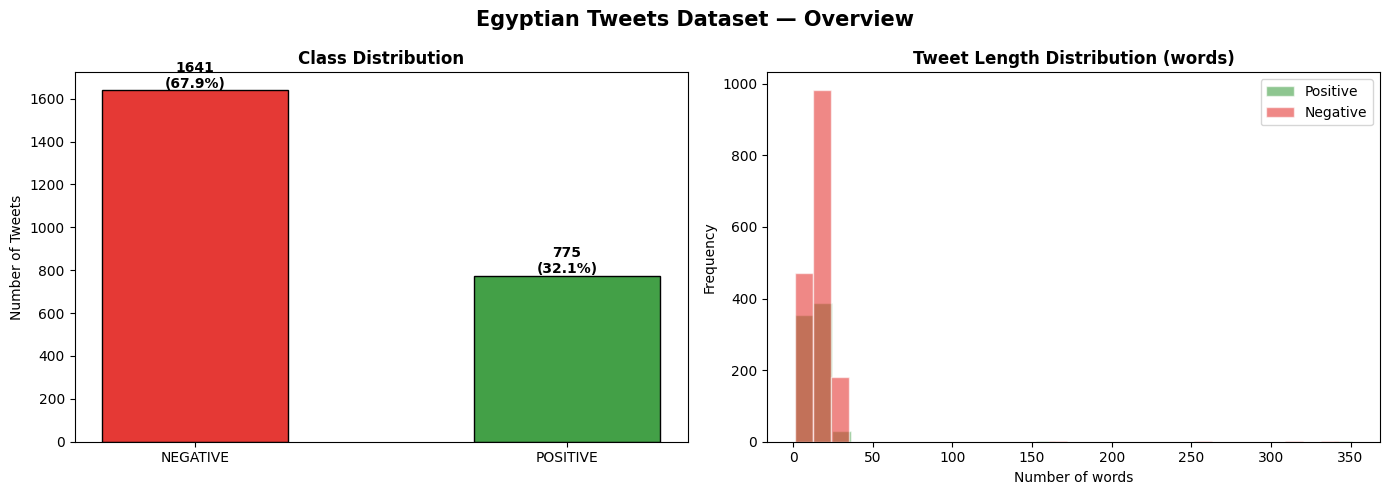

Note: dataset is imbalanced - more negative tweets than positive.


In [11]:
# =============================================
# PART 4a: class balance + tweet length
# =============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Egyptian Tweets Dataset Overview', fontsize=15, fontweight='bold')

counts = df['label'].value_counts()
bars = axes[0].bar(['NEGATIVE','POSITIVE'] if counts.index[0]=='NEG' else ['POSITIVE','NEGATIVE'],
                   counts.values, color=['#E53935','#43A047'], edgecolor='black', width=0.5)
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Number of Tweets')
for b, v in zip(bars, counts.values):
    axes[0].text(b.get_x()+b.get_width()/2, v+10, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')

for lbl, c in [('POS','#43A047'), ('NEG','#E53935')]:
    axes[1].hist(df[df['label']==lbl]['word_count'], bins=30, alpha=0.6, color=c,
                 label='Positive' if lbl=='POS' else 'Negative', edgecolor='white')
axes[1].set_title('Tweet Length Distribution (words)', fontweight='bold')
axes[1].set_xlabel('Number of words'); axes[1].set_ylabel('Frequency'); axes[1].legend()

plt.tight_layout(); plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight'); plt.show()
print("Note: dataset is imbalanced - more negative tweets than positive.")


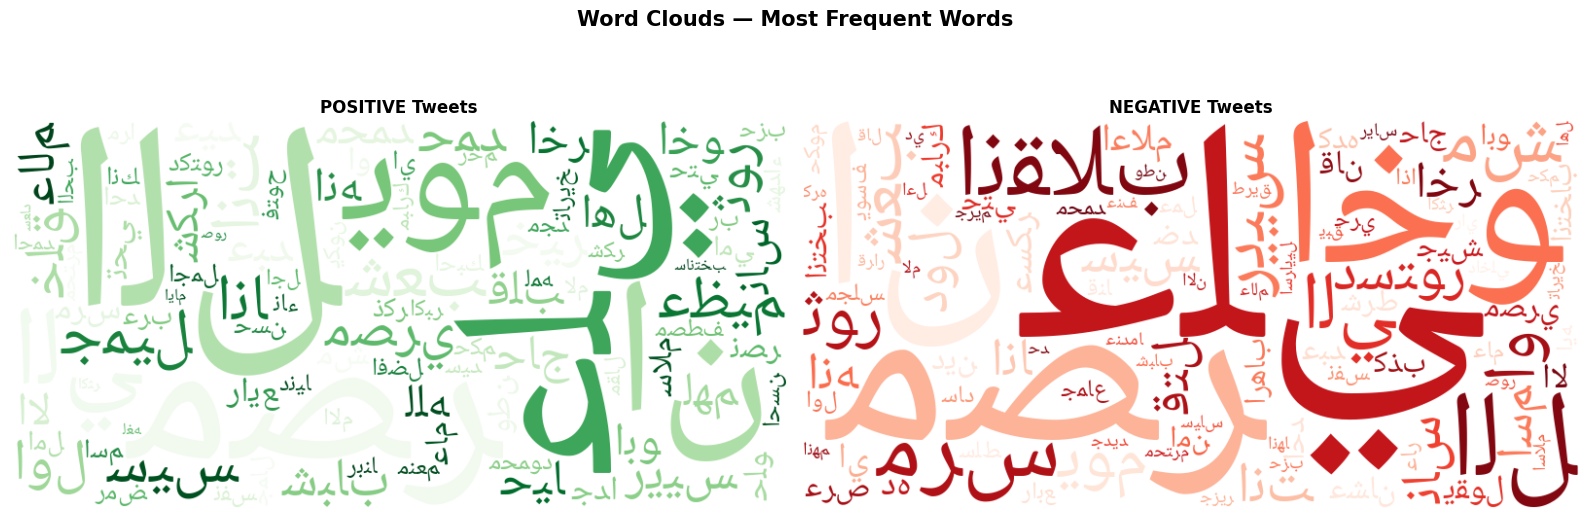

In [12]:
# =============================================
# PART 4b: Word Clouds (Arabic)
# =============================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Word Clouds: Most Frequent Words', fontsize=15, fontweight='bold')

for axx, lbl, cmap, title in [(axes[0],'POS','Greens','POSITIVE'),
                              (axes[1],'NEG','Reds','NEGATIVE')]:
    text = ' '.join(df[df['label']==lbl]['clean_tweet'])
    reshaped = ar(text)                                  # fix Arabic shaping/order
    wc = WordCloud(font_path=FONT_PATH, width=800, height=400,
                   background_color='white', colormap=cmap,
                   max_words=100, collocations=False).generate(reshaped)
    axx.imshow(wc, interpolation='bilinear')
    axx.set_title(f'{title} Tweets', fontweight='bold')
    axx.axis('off')

plt.tight_layout(); plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight'); plt.show()


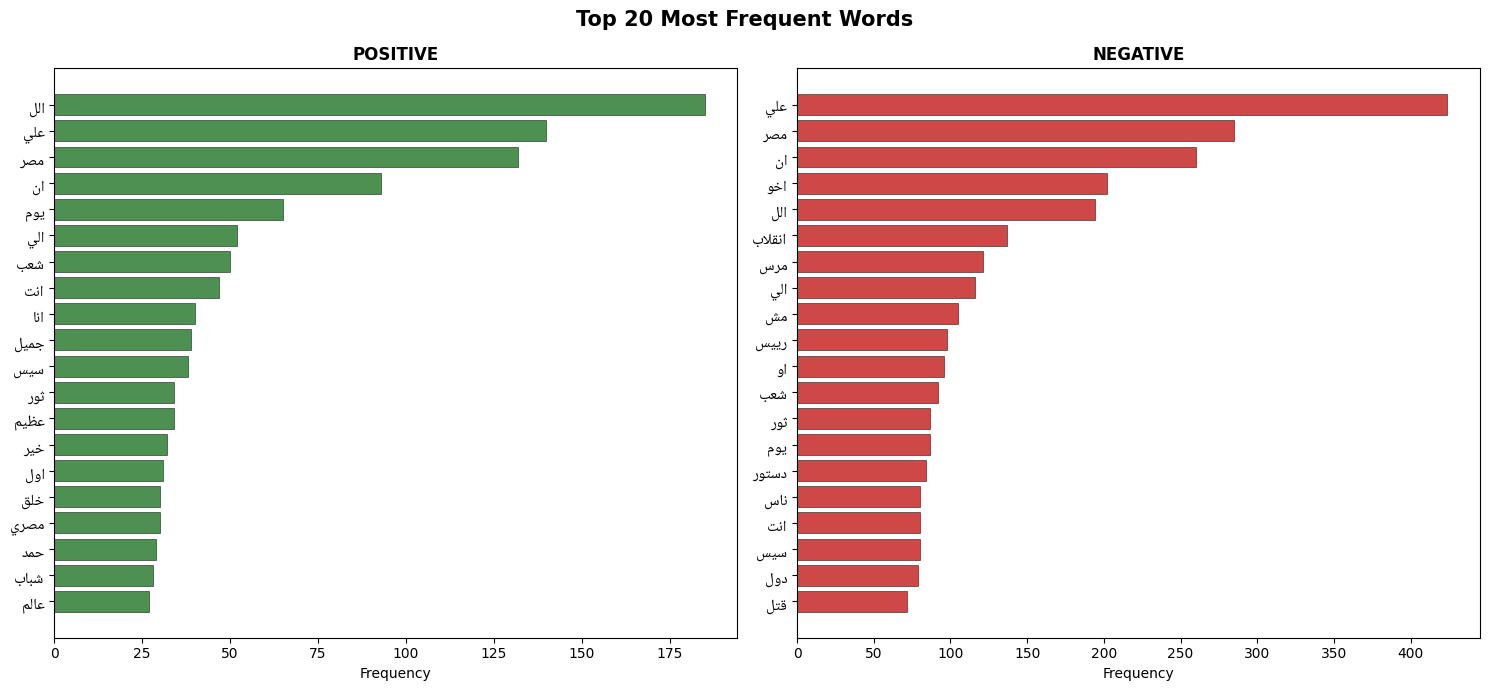

In [13]:
# =============================================
# PART 4c: Top 20 words bar plot
# =============================================
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
fig.suptitle('Top 20 Most Frequent Words', fontsize=15, fontweight='bold')

for axx, lbl, color, title in [(axes[0],'POS','#2E7D32','POSITIVE'),
                               (axes[1],'NEG','#C62828','NEGATIVE')]:
    words = ' '.join(df[df['label']==lbl]['clean_tweet']).split()
    top = Counter(words).most_common(20)
    labels = [ar(w) for w, _ in top]     # reshape for display
    vals   = [c for _, c in top]
    y_pos = np.arange(len(labels))
    axx.barh(y_pos, vals[::-1], color=color, alpha=0.85, edgecolor='black', linewidth=0.4)
    axx.set_yticks(y_pos)
    axx.set_yticklabels(labels[::-1], fontproperties=arabic_font, fontsize=11)  # Arabic font here only
    axx.set_title(f'{title}', fontweight='bold')
    axx.set_xlabel('Frequency')

plt.tight_layout(); plt.savefig('top_words.png', dpi=150, bbox_inches='tight'); plt.show()


## Part 5: Text Classification

I train 3 classifiers on the TF-IDF features and compare them:
1. **Naive Bayes (MultinomialNB)** fast text-classification baseline.
2. **Logistic Regression** linear, works great with TF-IDF.
3. **SVM (LinearSVC)** usually strongest for text.

Because the dataset is **imbalanced** (more NEG than POS), I use `class_weight='balanced'` for LogReg and SVM so the model doesn't just predict "negative" all the time. Split is **80% train / 20% test**, stratified.

> Something about arabic: results here are around ~75% accuracy, not 99% like you'd see on English spam. That's Kindda expected Arabic dialect sentiment is genuinely a harder as a problem.


In [14]:
# =============================================
# PART 5: Train/Test split
# =============================================
y = LabelEncoder().fit_transform(df['label'])   # NEG=0, POS=1
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape[0]} tweets | Test: {X_test.shape[0]} tweets")
print(f"Positive ratio  train: {y_train.mean():.1%}  test: {y_test.mean():.1%}")


Train: 1932 tweets | Test: 484 tweets
Positive ratio  train: 32.1%  test: 32.0%


In [15]:
# =============================================
# PART 5: Train & evaluate all models
# =============================================
models = {
    'Naive Bayes':         MultinomialNB(alpha=0.5),
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'SVM (LinearSVC)':     LinearSVC(class_weight='balanced', max_iter=2000, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    results[name] = {
        'Accuracy':  accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall':    recall_score(y_test, pred),
        'F1 Score':  f1_score(y_test, pred),
        'pred': pred
    }
    print(f"\n{'='*48}\n  {name}\n{'='*48}")
    print(classification_report(y_test, pred, target_names=['Negative','Positive']))



  Naive Bayes
              precision    recall  f1-score   support

    Negative       0.82      0.94      0.88       329
    Positive       0.81      0.56      0.66       155

    accuracy                           0.82       484
   macro avg       0.82      0.75      0.77       484
weighted avg       0.82      0.82      0.81       484


  Logistic Regression
              precision    recall  f1-score   support

    Negative       0.86      0.84      0.85       329
    Positive       0.67      0.70      0.69       155

    accuracy                           0.79       484
   macro avg       0.76      0.77      0.77       484
weighted avg       0.80      0.79      0.79       484


  SVM (LinearSVC)
              precision    recall  f1-score   support

    Negative       0.85      0.84      0.85       329
    Positive       0.67      0.70      0.68       155

    accuracy                           0.79       484
   macro avg       0.76      0.77      0.77       484
weighted avg     

=== Model Comparison ===
                     Accuracy  Precision  Recall  F1 Score
Naive Bayes            0.8182     0.8131  0.5613    0.6641
Logistic Regression    0.7934     0.6687  0.7032    0.6855
SVM (LinearSVC)        0.7934     0.6708  0.6968    0.6835


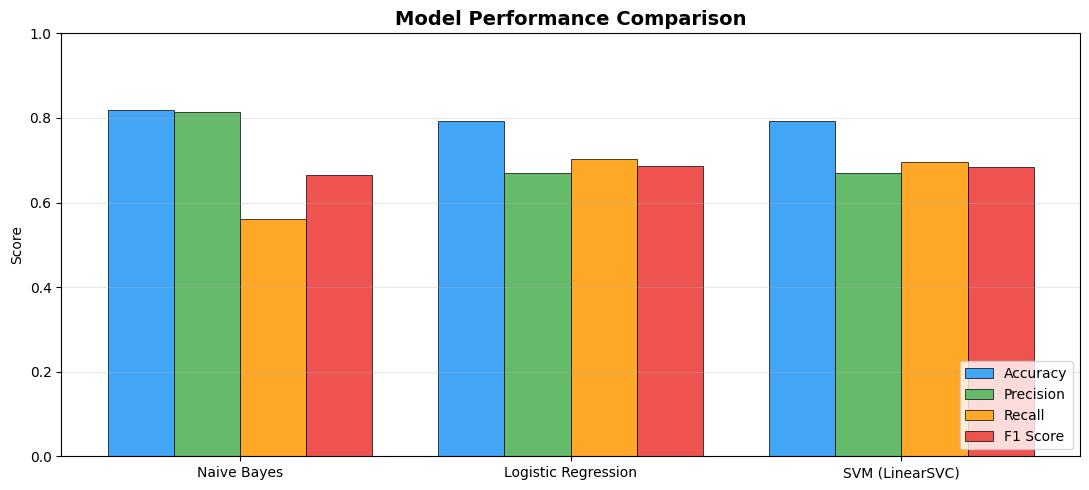


Best model by F1: Logistic Regression (0.686)


In [16]:
# =============================================
# PART 5: Comparison table + chart
# =============================================
metrics = ['Accuracy','Precision','Recall','F1 Score']
res_df = pd.DataFrame({n:{m:results[n][m] for m in metrics} for n in results}).T
print("=== Model Comparison ===")
print(res_df.round(4).to_string())

fig, axx = plt.subplots(figsize=(11,5))
x = np.arange(len(res_df)); w = 0.2
colors = ['#42A5F5','#66BB6A','#FFA726','#EF5350']
for i, m in enumerate(metrics):
    axx.bar(x+i*w, res_df[m].values, w, label=m, color=colors[i], edgecolor='black', linewidth=0.5)
axx.set_xticks(x+w*1.5); axx.set_xticklabels(res_df.index)
axx.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
axx.set_ylabel('Score'); axx.set_ylim(0,1); axx.legend(loc='lower right'); axx.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight'); plt.show()

best = res_df['F1 Score'].idxmax()
print(f"\nBest model by F1: {best} ({res_df.loc[best,'F1 Score']:.3f})")


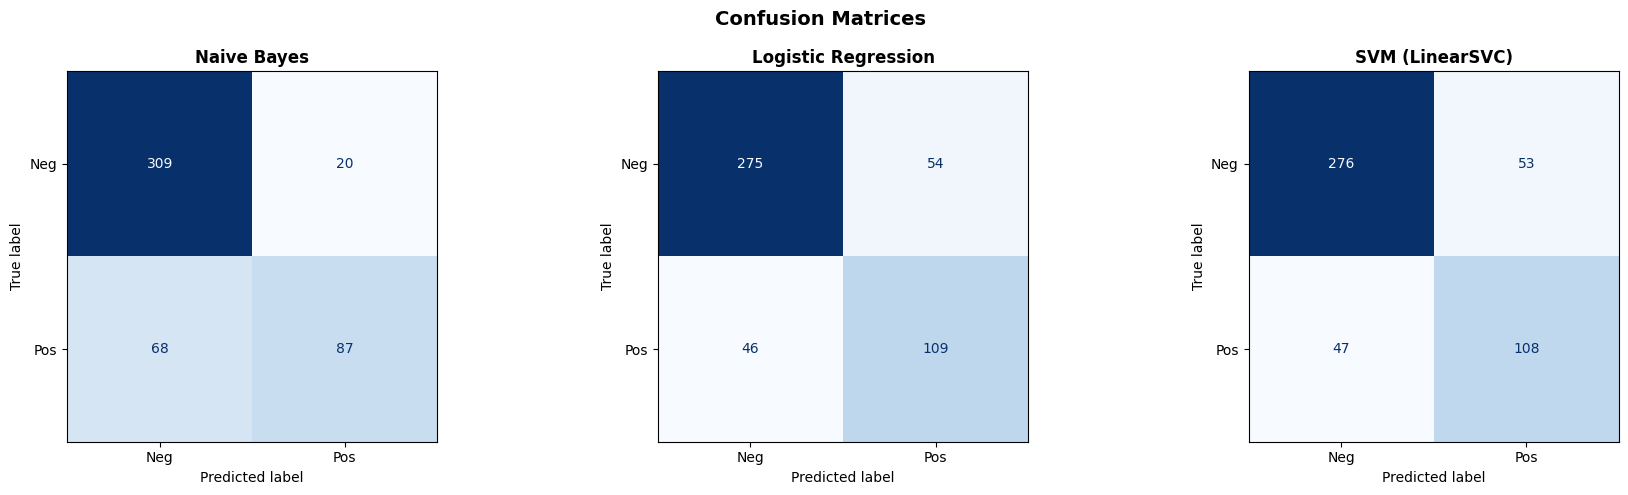

In [17]:
# =============================================
# PART 5: Confusion matrices
# =============================================
fig, axes = plt.subplots(1, 3, figsize=(18,5))
fig.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
for axx, name in zip(axes, models):
    ConfusionMatrixDisplay.from_predictions(
        y_test, results[name]['pred'], display_labels=['Neg','Pos'],
        ax=axx, cmap='Blues', colorbar=False)
    axx.set_title(name, fontweight='bold')
plt.tight_layout(); plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight'); plt.show()


### Discussion

A few honest observations:

- **Naive Bayes** gets decent accuracy but its **recall on the positive class is low** — because the data is imbalanced, it leans toward predicting "negative". That's why accuracy alone is misleading here, F1 is the metric to trust.
- **Logistic Regression** and **SVM** with `class_weight='balanced'` give a much better balance between precision and recall on the minority (positive) class.
- Overall ~75% accuracy is really good for Arabic dialect sentiment with TF-IDF. To push higher, I think if we need to make this more accurate we might use very specific niche tools, to Arabic Grammer stuff.

The main difficulty is dialect: In Egypt (Egyptians) we spell the same word in 3-4 ways, and ISRI stemming sometimes over-stems and merges unrelated words. Still, the models clearly learned something — they're well above the 50% random baseline.


## Part 6: Theory Questions

---

### Q1: Difference between text classification and text clustering

**Text Classification** is *supervised* learning. I already have labeled examples and a fixed set of categories known in advance, and the model learns to assign new text to one of those known categories. In this notebook, I had labeled tweets (POS/NEG) and trained a model to predict the label of new tweets.

**Text Clustering** is *unsupervised* learning. There are no labels. The algorithm groups similar documents together on its own and *discovers* the structure of the data. We don't tell it the categories. it finds natural groupings based on similarity.

| | Classification | Clustering |
|--|----------------|------------|
| Learning type | Supervised | Unsupervised |
| Labels needed | Yes | No |
| Categories | Known beforehand | Discovered |
| Goal | Assign to known class | Find hidden groups |
| Example | Tweet sentiment (this notebook) | Grouping news by topic |

> **Reference:** Manning, C.D., Raghavan, P., & Schütze, H. (2008). *Introduction to Information Retrieval*, Cambridge University Press. Chapter 16 (Flat Clustering), Section 16.1, paragraph 1: clustering is described as grouping objects so that objects in the same group are more similar to each other than to those in other groups — and it is contrasted with classification (Ch. 13) as the key difference being the absence of predefined classes / supervision.

---

### Q2: When is text clustering useful? Use cases

Clustering is the right tool when we **don't have labels** or **don't know the categories in advance**. Examples:

1. **Topic discovery**: say you scrape 50,000 Egyptian tweets about the economy. You don't know the sub-topics. Clustering groups them automatically (prices, fuel, salaries...) so you can explore them.
2. **News aggregation**: grouping articles about the same event together (like Google News does).
3. **Customer feedback analysis**: a company dumps thousands of unlabeled reviews; clustering reveals the main complaint themes without manual reading.
4. **Exploratory data analysis**: when you first get an unfamiliar dataset and want to understand its structure.
5. **Trend / event detection** on social media in real time.

> **Reference:** Aggarwal, C.C., & Zhai, C. (2012). *Mining Text Data*, Springer, Chapter 4 ("A Survey of Text Clustering Algorithms"), Section 4.1, paragraph 2: text clustering is presented as especially useful for organizing large unlabeled document collections and discovering natural groupings when no prior category structure is known. See also Xu, R. & Wunsch, D. (2005), *Survey of Clustering Algorithms*, IEEE Trans. Neural Networks 16(3), Section IV (applications).

---

### Q3: Determining the optimal number of clusters K in K-means

K-means needs you to choose K in advance, but you usually don't know the right value. Two common methods:

**Method 1: The Elbow Method.** Run K-means for a range of K values (e.g. 1–15). For each K, compute the **WCSS** (Within-Cluster Sum of Squares = total squared distance of points to their cluster center). WCSS always decreases as K increases, but at some point the improvement becomes tiny. When you plot WCSS vs K, that turning point looks like an "elbow" — and that K is the optimal choice (the point of diminishing returns).

> **Reference:** Thorndike, R.L. (1953). *Who Belongs in the Family?*, Psychometrika 18(4), pp. 267–276. Pages 267–268: introduces choosing the cluster count at the point where adding more clusters stops meaningfully reducing within-group distance — the basis of the elbow method.

**Method 2: Silhouette Analysis.** For each point, compute a silhouette score:

$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

where `a(i)` = average distance to points in its own cluster (cohesion) and `b(i)` = average distance to points in the nearest other cluster (separation). The score ranges from **-1 to +1**: near +1 means the point is well-clustered, near 0 means it's on a boundary, negative means it's probably mis-assigned. You compute the **average silhouette across all points for each K** and pick the K with the highest average. It's often more reliable than the elbow because it gives a clear numeric score instead of a subjective "where's the elbow?".

> **Reference:** Rousseeuw, P.J. (1987). *Silhouettes: a graphical aid to the interpretation and validation of cluster analysis*, Journal of Computational and Applied Mathematics, 20, pp. 53–65. Page 53 (Abstract) defines the silhouette as showing how well each object lies within its cluster; the formula s(i) is given in Section 2, Equation (1).


## Summary

So to wrap everything up:

- **Part 0:** I found an article about how hard Arabic sentiment analysis is, and why classification helps.
- **Part 1:** used the ASTD dataset: real Egyptian tweets, kept the POS/NEG ones (~2,400 tweets).
- **Part 2:** cleaned Arabic text properly, normalization (alef/ya/ta-marbuta, removing diacritics + tatweel), tokenization, Arabic stopwords, and ISRI stemming.
- **Part 3:** TF-IDF + Word2Vec (skip-gram) on Arabic, the embeddings even learned related words.
- **Part 4:** EDA with Arabic word clouds + top-word bars (had to use reshaping + bidi + a Noto Arabic font to make Arabic display correctly).
- **Part 5:** trained Naive Bayes, Logistic Regression and SVM. Got ~75% accuracy. Used `class_weight='balanced'` to deal with the imbalance.
- **Part 6:** answered the theory questions with paper references.

The biggest lesson for me: Arabic NLP is genuinely harder than English because of the dialect and rich morphology, and the standard English tutorial pipeline doesn't just work out of the box, you have to add normalization and Arabic-specific tools. It Was fun to me though. ^-^

